In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from time import time

import sys 
sys.path.append('..')

from PyESRSTM import QD, Electrode, units, rates, ESR, sum_rates, QME_matrix, QME, current
from PyESRSTM.postproces.dynamics import Bexch, Trel, Szacc

from scipy.optimize import curve_fit

In [2]:
#    eps[meV],U[meV],       spins,                                  Magnetic field[T],        Gyromagnetic factor
dot = QD(-30, 100, np.array([0.5]), np.array([[0.20804273,  0.00000000,  0.57159271]]), np.array([[2.0, 2.0, 2.0]]))
print(dot)

Hermiticity check passed!
idx 	Occup 	Energy [meV] 	Spin central 	Spin total
				 x,  y,  z 	 x,  y,  z
0	1 	-30.035209352 	-0.2 -0.0 -0.5 	-0.2 -0.0 -0.5
1	1 	-29.964790648 	0.2 0.0 0.5 	0.2 0.0 0.5
2	0 	0.000000000 	0.0 0.0 0.0 	0.0 0.0 0.0
3	2 	40.000000000 	0.0 0.0 0.0 	0.0 0.0 0.0


In [3]:
#               Vdc, VRF, P,  coupling, broadening  Temperature,
Right = Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = Electrode(-32, 0, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000)

GRp, GRm = rates(dot, Right, 20, 0)
GLp, GLm = rates(dot, Left, 20, 0)
print(GLp.shape)

(4, 4, 4, 4, 1)


In [4]:
import matplotlib
import matplotlib.gridspec as gridspec


def plot_cm(x, y, z, iS, iB):
    
    STT = x[iS]
    FLT = y[iB]
    
    fig = plt.figure()

    gs = gridspec.GridSpec(3,3, figure=fig)
    ax0 = fig.add_subplot(gs[1:,:-1])
    ax1 = fig.add_subplot(gs[0,:-1], sharex=ax0)
    ax2 = fig.add_subplot(gs[1:,-1], sharey=ax0)

    maxval = np.max(z)
    minval = np.min(z)
    if minval>0:
    #minval = 0
        cm='Blues'
    elif maxval<0:
    #maxval=0
        cm='Reds'
    else:
        maxval = max(-minval, maxval)
        minval =-maxval 
        cm='seismic'

    norm = matplotlib.colors.Normalize(vmin=minval, vmax=maxval)
    ax0.tricontourf(x, y, z, levels=int(len(z)), cmap=cm, norm=norm)
    
    ax0.vlines([STT], *ax0.get_ylim(), 'g', '--')
    ax0.hlines([FLT], *ax0.get_xlim(), 'g', '--')

    #ax0.set_ylim(0,np.pi)
    #ax0.set_yticks(np.pi*np.array([0, 1/4, 1/2, 3/4, 1]), [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$',r'$\pi$'])
    #ax0.set_xticks([-35, -30, -25], [r'$\epsilon-V_{RF}$', r'$\epsilon$', r'$\epsilon+V_{RF}$',])
    ax0.set_xlabel(r'$\langle S_z\rangle_{acc,1}$ [MHz]')
    ax0.set_ylabel(r'$B_{xc,1}$ [MHz]')

    use = (x==STT)
    ax2.plot(z[use], y[use])
    plt.setp(ax2.get_yticklabels(), visible=False)
    #ax2.text(np.max(z[use])*.95+.05*np.min(z[use]), .95*np.pi, r'$STT=$'+f'{STT:.1f} mV', ha='right', va='top')

    use = (y==FLT)
    ax1.plot( x[use], z[use],)
    plt.setp(ax1.get_xticklabels(), visible=False)
    #ax1.text(-39,np.max(z[use])*.95+.05*np.min(z[use]), r'$FLT=$'+f'{FLT:.1f} deg', va='top')

    return fig, ax0, ax1, ax2

In [5]:
FLT_comp = (np.array([1,1,0,0]), np.array([2,3,2,3]), np.array([2,3,2,3]), np.array([0,0,1,1]))
STT_comp = (np.array([2,2,3,3]), np.array([0,1,0,1]), np.array([0,1,0,1]), np.array([2,2,3,3]))


def add_driving(G, A, comp, part='all'):
    new_shape = list(G.shape)[:-1]
    G = G.reshape(new_shape)
    drive = np.zeros_like(G)
    drive[comp] = A 

    if part=='all':
        fun = lambda x: x
    elif part=='real':
        fun = lambda x: np.real(x)
    elif part == 'imag':
        fun = lambda x: 1j*np.imag(x)
        
    G_new = np.empty(new_shape+[3], dtype=complex)
    G_new[:,:,:,:,0] = fun(G)*drive
    G_new[:,:,:,:,2] = fun(G)*drive
    return G_new

def peak_dyn(FLT_drive, STT_drive, p0=None, p0_S=None):
    comp = (np.array([1,1,0,0]), np.array([2,3,2,3]), np.array([2,3,2,3]), np.array([0,0,1,1]))
    GLp_driv = add_driving(GLp, FLT_drive, comp, 'imag') + add_driving(GLp, STT_drive, comp, 'real')
    GLm_driv = add_driving(GLm, FLT_drive, comp, 'imag') + add_driving(GLm, STT_drive, comp, 'real')

    GLm_driv[:,:,:,:,1] = GLm[:,:,:,:,0]
    GLp_driv[:,:,:,:,1] = GLp[:,:,:,:,0]

    frequencies = np.linspace(15,20,1000)
    GL = GLp_driv + GLm_driv
    GR = GRm + GRp

    G = sum_rates(GL, GR)
    
    Ndim = G.shape[0]
    NF = G.shape[-1]

    GC = GLp_driv-GLm_driv
    I = np.zeros((len(frequencies), NF))
    S = np.zeros((len(frequencies), 3, NF))

    M = QME_matrix(G, dot.Delta, )
    for i, f in enumerate(frequencies):
        rho = QME(M.copy(), f, qme_matrix=True)
        I[i] = np.real(current(rho,GC))
        S[i,0,:] = .5*np.real(rho[0,1] + np.conj(rho[1,0]))
        S[i,1,:] = .5*np.imag(rho[0,1] - np.conj(rho[1,0]))
        S[i,2,:] = .5*np.real(rho[1,1] - rho[0,0])


    if p0 is None:
        p0 = ESR.guess_p0(frequencies, I[:,1], dot.Delta[0,1]*units.Hartree/units.GHz)

    try:
        popt, _  = curve_fit(ESR.ESR_fit_fun, frequencies, I[:,1], p0 = p0, maxfev=10000)
    except:
        popt = np.zeros_like(p0)

    # Sorry for this abomination
    popt_S = np.empty((3, NF, len(popt)))

    for i in range(3):
        for n in range(NF):
            if p0_S is None:
                p0 = ESR.guess_p0(frequencies, S[:,i,n], dot.Delta[0,1]*units.Hartree/units.GHz)
            else: 
                p0 = p0_S[i,n]
            try:
                popt_S[i,n], _ = curve_fit(ESR.ESR_fit_fun, frequencies, S[:,i,n], p0 = p0, maxfev=10000)
            except:
                popt_S[i,n] = np.zeros_like(p0)
    
    Bxc = np.sum(np.imag(GL[:,:,:,:,0][comp]))
    Sz = np.sum(np.real(GL[:,:,:,:,0][comp]))
    return popt, Bxc, Sz, popt_S


In [6]:

STT_drive = np.linspace(-1,1,20)
FLT_drive = np.linspace(-1,1,20)

Is = np.empty((len(FLT_drive),len(STT_drive)))
Ia = np.empty_like(Is)
gamma = np.empty_like(Is)
Lamb = np.empty_like(Is)

B1 = np.empty_like(Is)
T1 = np.empty_like(Is)
Sz1 = np.empty_like(Is)

popt_S_all = np.empty((len(FLT_drive),len(STT_drive),3,3,4))
for i, FLT in enumerate(FLT_drive):
    p0 = None
    p0_S = None
    for j, STT in enumerate(STT_drive):

        popt, B1[i,j], Sz1[i,j], popt_S = peak_dyn(FLT, STT, p0, p0_S)
        Lamb[i,j], gamma[i,j], Is[i,j], Ia[i,j] = popt[:4]
        
        popt_S_all[i,j] = popt_S[:,:,:4]
        
        Ia *= np.sign(gamma)
        gamma *= np.sign(gamma)

        
        p0 = popt
        p0_S = popt_S



/home/matyas/Programs/PyESRSTM/Tutorial/../PyESRSTM/Floquet/ESR.py:89: RuntimeWarning: divide by zero encountered in divide
  y = 2*(x - res)/gamma
/home/matyas/Programs/PyESRSTM/Tutorial/../PyESRSTM/Floquet/ESR.py:92: RuntimeWarning: invalid value encountered in multiply
  nominator = Isym + 2*Iasym * y
/home/matyas/Programs/PyESRSTM/Tutorial/../PyESRSTM/Floquet/ESR.py:94: RuntimeWarning: invalid value encountered in divide
  peak = nominator / denominator


In [7]:
popt_S_all[:,:,:,:,3] *=  np.sign(popt_S_all[:,:,:,:,1])

Text(0.5, 0, '$\\Delta I_a$ [pa]')

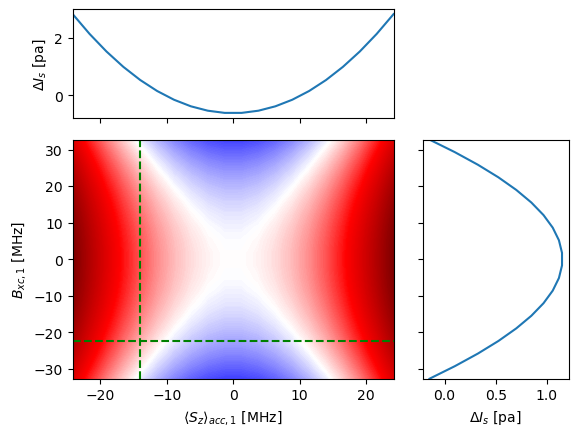

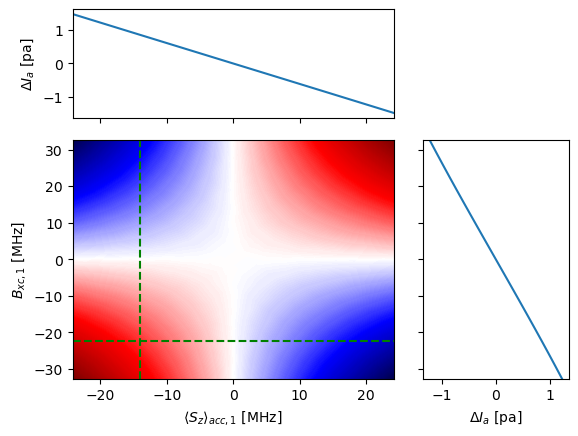

In [8]:
fig, ax0, ax1, ax2 = plot_cm(Sz1.flatten()*units.Hartree/units.GHz*1000, B1.flatten()*units.Hartree/units.GHz*1000, Is.flatten(), 15, 70)
ax1.set_ylabel(r'$\Delta I_s$ [pa]')
ax2.set_xlabel(r'$\Delta I_s$ [pa]')

fig, ax0, ax1, ax2 = plot_cm(Sz1.flatten()*units.Hartree/units.GHz*1000, B1.flatten()*units.Hartree/units.GHz*1000, Ia.flatten(), 15, 70)
ax1.set_ylabel(r'$\Delta I_a$ [pa]')
ax2.set_xlabel(r'$\Delta I_a$ [pa]')

The above confirms previous papers, clearly $\langle S_z\rangle_{acc;1}$ and $B_{xc;1}$ lead to opposite sing on the $\Delta I_s$. $\Delta I_a$ is zero when only one driving is present. Newly we see that the sign $Delta I_a$ depends on the relative sign of the two driving.

Next we use the following relation $\Delta I \approx \frac{8e}{\hbar} P_L \left[\Re \left\{ \Gamma^{+0}_{g00g,L;0} \right\} \Delta S'_{z;0} \cos{\theta} +\Re\left\{\Gamma_{g00g,L;1}^{+0}\right\} \Delta S'_{x;1} \sin\theta\right]$ and examine the contribution of each spin component.

Text(0.5, 0, '$\\Delta \\langle S_{z,0}\\rangle_a$')

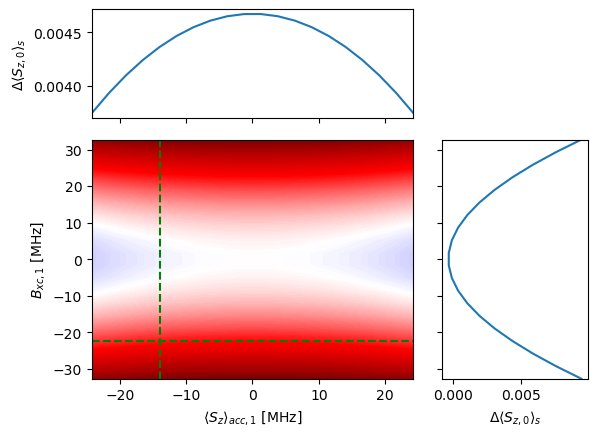

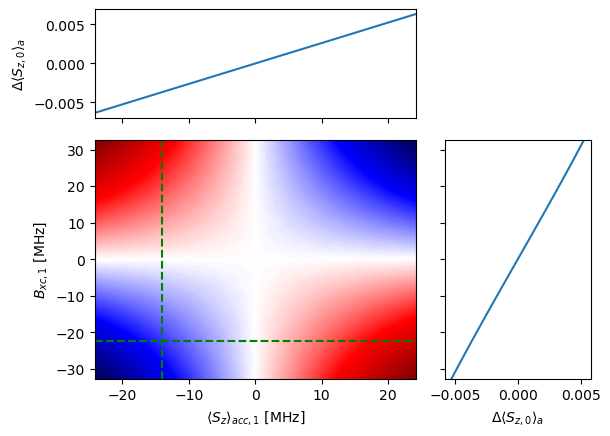

In [9]:
fig, ax0, ax1, ax2 = plot_cm(Sz1.flatten()*units.Hartree/units.GHz*1000, B1.flatten()*units.Hartree/units.GHz*1000, popt_S_all[:,:,2,1,2].flatten(), 15, 70)
ax1.set_ylabel(r'$\Delta \langle S_{z,0}\rangle_s$')
ax2.set_xlabel(r'$\Delta \langle S_{z,0}\rangle_s$')

fig, ax0, ax1, ax2 =  plot_cm(Sz1.flatten()*units.Hartree/units.GHz*1000, B1.flatten()*units.Hartree/units.GHz*1000, popt_S_all[:,:,2,1,3].flatten(), 15, 70)
ax1.set_ylabel(r'$\Delta \langle S_{z,0}\rangle_a$')
ax2.set_xlabel(r'$\Delta \langle S_{z,0}\rangle_a$')

Text(0.5, 0, '$\\Delta \\langle S_{x,1}\\rangle_a$')

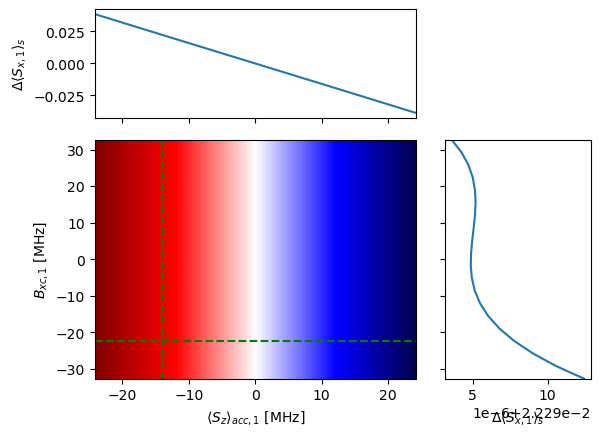

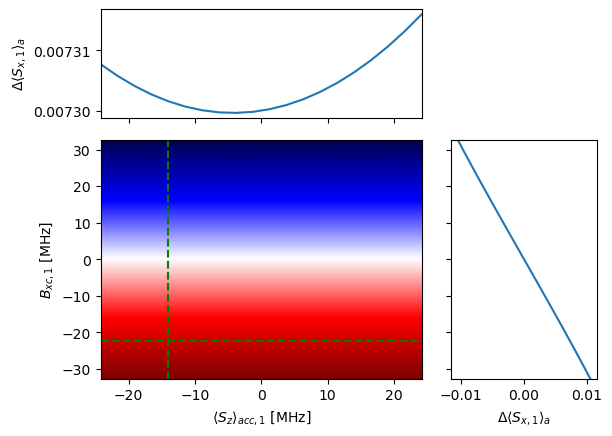

In [10]:
fig, ax0, ax1, ax2 = plot_cm(Sz1.flatten()*units.Hartree/units.GHz*1000, B1.flatten()*units.Hartree/units.GHz*1000, popt_S_all[:,:,0,2,2].flatten(), 15, 70)
ax1.set_ylabel(r'$\Delta \langle S_{x,1}\rangle_s$')
ax2.set_xlabel(r'$\Delta \langle S_{x,1}\rangle_s$')

fig, ax0, ax1, ax2 =  plot_cm(Sz1.flatten()*units.Hartree/units.GHz*1000, B1.flatten()*units.Hartree/units.GHz*1000, popt_S_all[:,:,0,2,3].flatten(), 15, 70)
ax1.set_ylabel(r'$\Delta \langle S_{x,1}\rangle_a$')
ax2.set_xlabel(r'$\Delta \langle S_{x,1}\rangle_a$')

Text(0.5, 0, '$\\Delta \\langle S_{x,1}\\rangle_a$')

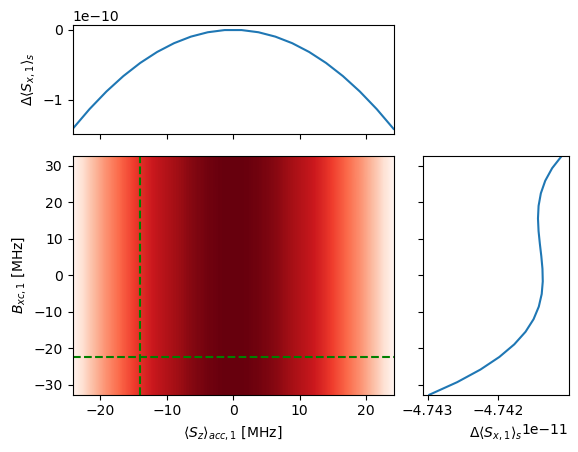

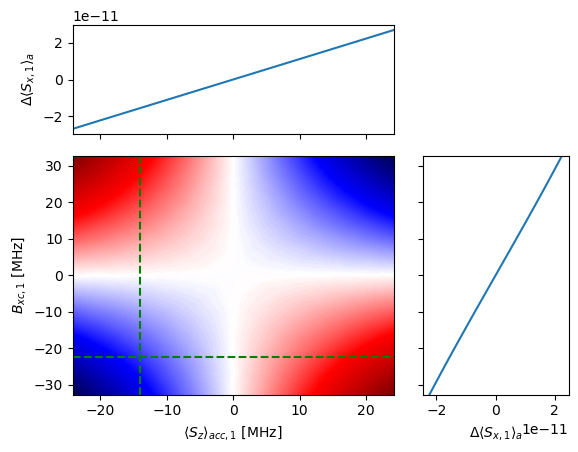

In [11]:
fig, ax0, ax1, ax2 = plot_cm(Sz1.flatten()*units.Hartree/units.GHz*1000, B1.flatten()*units.Hartree/units.GHz*1000, (popt_S_all[:,:,0,0,2]*Sz1).flatten(), 15, 70)
ax1.set_ylabel(r'$\Delta \langle S_{x,1}\rangle_s$')
ax2.set_xlabel(r'$\Delta \langle S_{x,1}\rangle_s$')

fig, ax0, ax1, ax2 =  plot_cm(Sz1.flatten()*units.Hartree/units.GHz*1000, B1.flatten()*units.Hartree/units.GHz*1000, (popt_S_all[:,:,0,0,3]*Sz1).flatten(), 15, 70)
ax1.set_ylabel(r'$\Delta \langle S_{x,1}\rangle_a$')
ax2.set_xlabel(r'$\Delta \langle S_{x,1}\rangle_a$')

(<Figure size 640x480 with 3 Axes>,
 <Axes: xlabel='$\\langle S_z\\rangle_{acc,1}$ [MHz]', ylabel='$B_{xc,1}$ [MHz]'>,
 <Axes: >,
 <Axes: >)

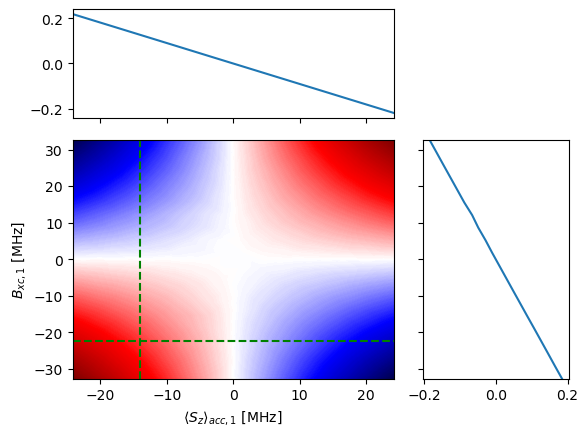

In [12]:
plot_cm(Sz1.flatten()*units.Hartree/units.GHz*1000, B1.flatten()*units.Hartree/units.GHz*1000, (Lamb.flatten()-np.mean(Lamb))*1000, 15, 70)

(<Figure size 640x480 with 3 Axes>,
 <Axes: xlabel='$\\langle S_z\\rangle_{acc,1}$ [MHz]', ylabel='$B_{xc,1}$ [MHz]'>,
 <Axes: >,
 <Axes: >)

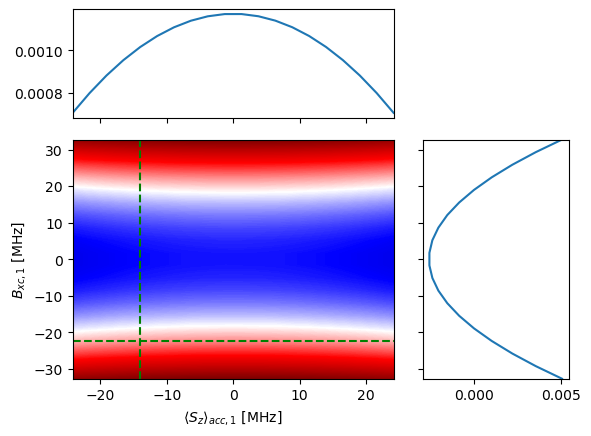

In [13]:
plot_cm(Sz1.flatten()*units.Hartree/units.GHz*1000, B1.flatten()*units.Hartree/units.GHz*1000, gamma.flatten()-gamma[15,15], 15, 70)